## Amanda Richardson's Week 8 Assignment

### Story 1: Predicting Car Resale Prices

Story 1: Predicting Car Resale Prices
You are a data analyst working for a company that specializes in predicting car resale values.
Your goal is to build a predictive model for the resale price of used cars based on key features.
The dataset includes the following variables:
• Mileage (miles_driven) – The total miles driven by the car.
• Car Age (age) – The number of years since the car was manufactured.
• Engine Size (engine_size) – The engine capacity in liters (e.g., 1.5L, 2.0L).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)
n = 200
miles_driven = np.random.uniform(5000, 150000, n)
age = np.random.randint(1, 21, n)
engine_size = np.random.uniform(1.2, 4.0, n)
price = (30000 - miles_driven * 0.05) + (engine_size * 4000) - (age * 1500) + np.random.normal(0, 2000, n)
df = pd.DataFrame({
    'miles_driven': miles_driven,
    'age': age,
    'engine_size': engine_size,
    'price': price
})

## 1. Please Perform Exploratory Data Analysis (EDA). Visualize the relationships between price and each predictor using scatter plots.

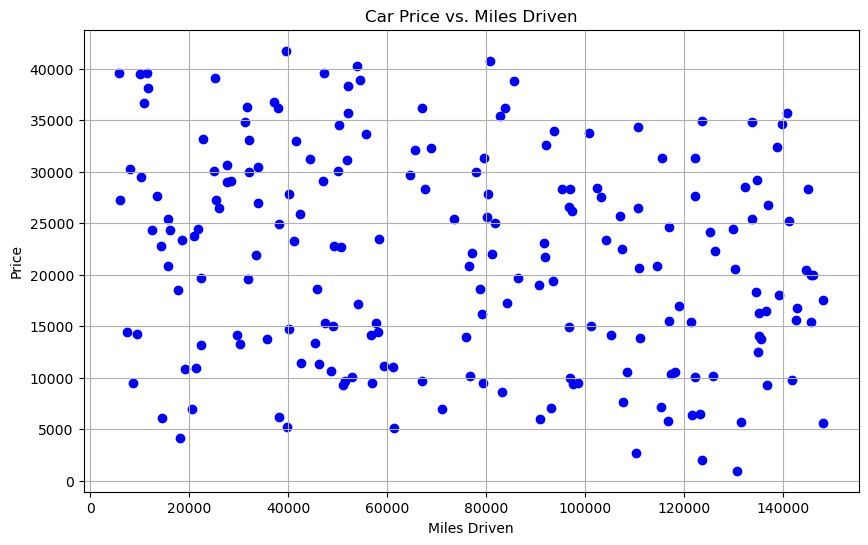

In [2]:
plt.figure(figsize=(10,6))
plt.scatter(df['miles_driven'], df['price'], color='blue')
plt.title('Car Price vs. Miles Driven')
plt.xlabel('Miles Driven')
plt.ylabel('Price')
plt.grid(True)
plt.show()

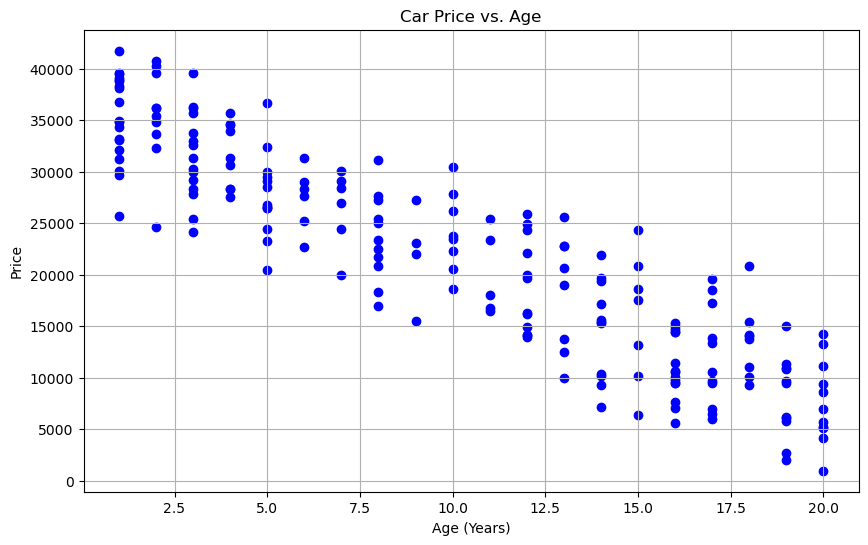

In [3]:
plt.figure(figsize=(10,6))
plt.scatter(df['age'], df['price'], color='blue')
plt.title('Car Price vs. Age')
plt.xlabel('Age (Years)')
plt.ylabel('Price')
plt.grid(True)
plt.show()

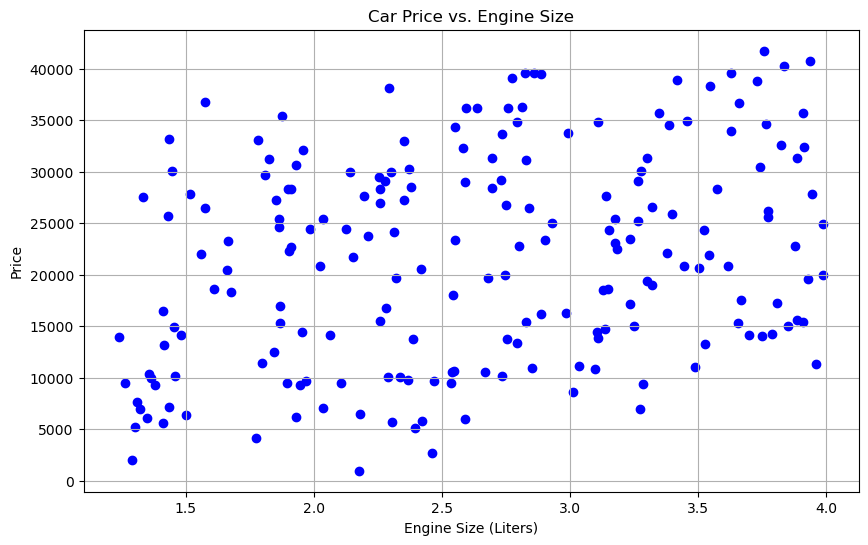

In [4]:
plt.figure(figsize=(10,6))
plt.scatter(df['engine_size'], df['price'], color='blue')
plt.title('Car Price vs. Engine Size')
plt.xlabel('Engine Size (Liters)')
plt.ylabel('Price')
plt.grid(True)
plt.show()

## 2. Fit an Ordinary Least Squares (OLS) regression model to predict the price based on miles_driven, age, and engine_size.

In [5]:
from sklearn.model_selection import train_test_split
X = df[['miles_driven', 'age', 'engine_size']]
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [6]:
import statsmodels.api as sm
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                  price   R-squared (uncentered):                   0.910
Model:                            OLS   Adj. R-squared (uncentered):              0.908
Method:                 Least Squares   F-statistic:                              530.2
Date:                Fri, 27 Feb 2026   Prob (F-statistic):                    6.76e-82
Time:                        05:39:16   Log-Likelihood:                         -1650.1
No. Observations:                 160   AIC:                                      3306.
Df Residuals:                     157   BIC:                                      3315.
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

## 3. Interpret the coefficients: What does each coefficient tell you about its impact on price?

miles_driven

coef = 0.0205, std err = 0.013, t = 1.640, p = 0.103,
95% CI = [−0.004, 0.045]

A 1-mile increase in mileage is associated with a $0.0205 increase in price, holding other variables constant. However, the effect is not statistically significant (p > 0.05), and the confidence interval includes zero, so we cannot conclude that mileage significantly impacts price.

age

coef = −1082.5625, std err = 88.329, t = −12.256, p = 0.000,
95% CI = [−1257.030, −908.096]

Each additional year of age decreases price by about $1,082.56, holding other variables constant. The effect is highly statistically significant (p < 0.001), and the confidence interval does not include zero.

engine_size

coef = 1.11e+04 (~11,100), std err = 445.235, t = 24.931, p = 0.000,
95% CI = [1.02e+04, 1.2e+04]

A 1-liter increase in engine size increases price by about $11,100, holding other variables constant. The effect is highly statistically significant (p < 0.001), and the confidence interval excludes zero.

## 4. Interpret the components in the OLS Regression Results

R-squared (uncentered): 0.910
The model explains 91.0% of the variation in price (strong fit).

Adj. R-squared (uncentered): 0.908
After adjustment, 90.8% of variation is explained; very close to R², indicating no overfitting.

F-statistic: 530.2
Tests overall model significance.
Prob (F-statistic): 6.76e−82 which is xtremely small (< 0.05), so the overall model is statistically significant.


AIC is 3306 and BIC is 3315
AIC tesls us about model selection criterion where lower is better. BIC is Similar to AIC but penalizes complexity more.


Jarque-Bera (JB) tests statistic is 3.829 and the Prob(JB): 0.147  since the thp > 0.05, so residuals are approximately normal.

Skew is  0.023 which suggests that the Residuals are nearly symmetric.

Kurtosis is 2.244 whichnSlightly below 3, indicating slightly lighter tails than normal.

Durbin-Watson is  1.705 which is close to 2, suggesting no strong autocorrelation.

## 5. Use each of the the model diagnostic tools, (i) Actual vs. Predicted values, (ii) Q-Q Plot, and (iii) Residual analysis and interpret the results.

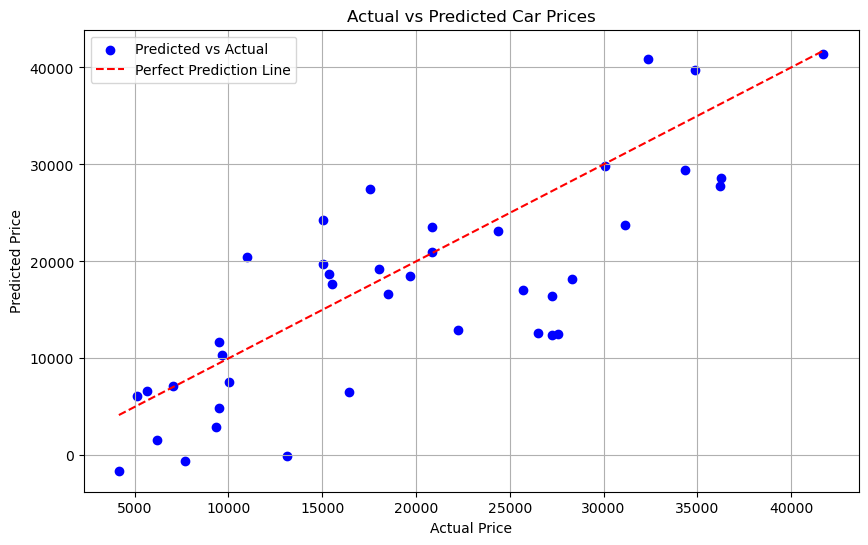

In [7]:
y_pred = model.predict(X_test)
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--',
         label='Perfect Prediction Line')
plt.title('Actual vs Predicted Car Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.grid(True)
plt.show()

Actual vs. Predicted Plot: 
The points are scattered in a roughly upward-sloping cloud, indicating that the model successfully captures the general trend that more expensive cars should have higher predicted values. However, the plot looks moderately dispersed, with several data points sitting far away from the "Perfect Prediction Line.

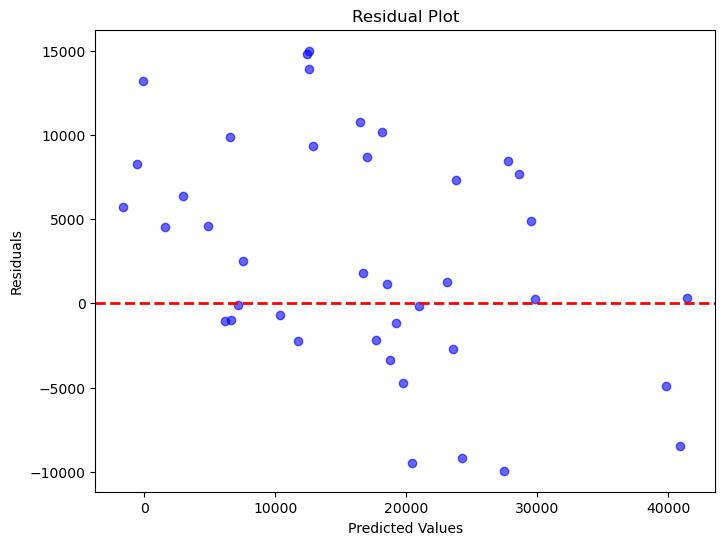

In [8]:
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

Since the points in your plot appear fairly distributed with no obvious "U-shape" or "funnel" pattern, it suggests that the assumption of linearity is met.

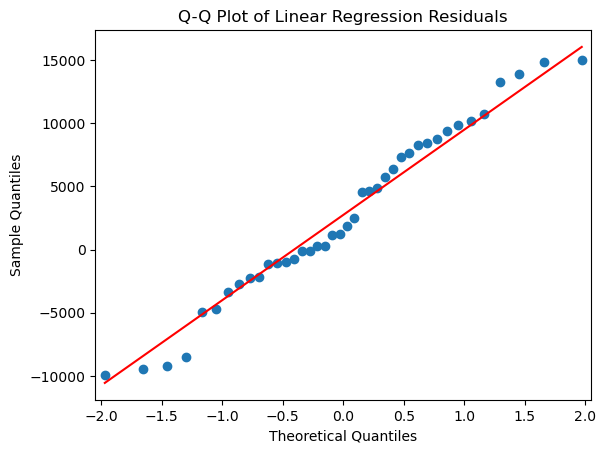

In [10]:
sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot of Linear Regression Residuals')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

The plot shows a tightly clustered string of points following a solid red diagonal line which confirms that the majority of your prediction errors are normally distributed.